Dataset:

LB - Likely stands for "Baseline Fetal Heart Rate (FHR)" which represents the average fetal heart rate over a period.

AC - Could represent "Accelerations" in the FHR. Accelerations are usually a sign of fetal well-being.

FM - May indicate "Fetal Movements" detected by the monitor.

UC - Likely denotes "Uterine Contractions", which can impact the FHR pattern.

DL - Could stand for "Decelerations Late" with respect to uterine contractions, which can be a sign of fetal distress.

DS - May represent "Decelerations Short" or decelerations of brief duration.

DP - Could indicate "Decelerations Prolonged", or long-lasting decelerations.

ASTV - Might refer to "Percentage of Time with Abnormal Short Term Variability" in the FHR.

MSTV - Likely stands for "Mean Value of Short Term Variability" in the FHR.

ALTV - Could represent "Percentage of Time with Abnormal Long Term Variability" in the FHR.

MLTV - Might indicate "Mean Value of Long Term Variability" in the FHR.


#Exploratory Data Analysis

In [2]:
import warnings
warnings.filterwarnings('ignore')

from collections import Counter # utility for counting items

# Import necessary packages
import pandas as pd
import numpy as np

In [3]:
# Load_Cardiotocographic_dataset
df = pd.read_csv('Cardiotocographic.csv')

In [4]:
df.sample(30)

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
553,140.000000,0.003336,0.000000,0.008340,0.003336,0.000000e+00,-0.000009,35.000000,5.000000,0.120864,29.300000,126.000000,1.000000,1.000000
2122,140.000000,0.000775,0.000000,0.006979,0.000000,0.000000e+00,0.000000,78.000000,0.400000,22.000000,7.100000,66.000000,1.000000,2.000000
947,142.000000,0.003058,0.000000,0.007136,0.003058,0.000000e+00,0.000000,30.000000,1.400000,0.000000,17.200000,83.000000,1.000000,1.000000
1264,119.000000,0.003820,0.000000,0.006686,0.000000,0.000000e+00,0.000000,24.000000,1.400000,2.000000,11.100000,42.485189,0.000000,1.000000
1936,133.000000,0.000000,0.003188,0.008502,0.003188,0.000000e+00,0.000000,63.000000,2.400000,0.000000,0.100000,39.000000,1.000000,1.000000
1510,130.000000,0.000000,0.000000,0.005208,0.000000,1.492949e-06,0.000000,52.000000,0.600000,44.000000,5.900000,30.000000,0.000000,1.000000
1179,126.000000,0.006061,0.000000,0.009524,0.000000,0.000000e+00,0.000000,27.444324,1.300000,0.000000,6.300000,43.000000,0.000000,1.000000
454,133.000000,0.000000,0.002554,0.002515,0.000000,0.000000e+00,0.000000,58.000000,0.500000,17.000000,8.900000,21.406222,0.000000,1.000000
697,131.000000,0.000829,0.369475,0.003336,0.003336,4.565852e-06,0.001668,29.000000,2.000000,-0.227319,8.100000,111.000000,1.000000,3.000000
380,140.524169,0.008000,0.024000,0.001600,0.001600,0.000000e+00,0.000000,50.000000,0.900000,1.000000,4.300000,114.000000,1.000000,1.000000


In [5]:
# Dataset Shape
df.shape

(2126, 14)

In [6]:
# columns name -- total count:14
df.columns

Index(['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV',
       'MLTV', 'Width', 'Tendency', 'NSP'],
      dtype='str')

In [7]:
# Data Types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


In [8]:
df.describe()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
count,2105.000000,2106.000000,2126.000000,2126.000000,2126.000000,2105.000000,2105.000000,2126.000000,2126.000000,2126.000000,2105.000000,2105.000000,2105.000000,2105.000000
mean,133.343598,0.003219,0.009894,0.004391,0.001895,0.000003,0.000175,46.995984,1.364378,10.285964,8.284887,70.429260,0.316371,1.304507
std,11.270154,0.004391,0.067540,0.003340,0.003343,0.000142,0.000840,18.813973,1.173632,21.205041,7.772858,42.931822,0.645622,0.644619
min,51.842487,-0.019284,-0.480634,-0.014925,-0.015393,-0.001353,-0.005348,-63.000000,-6.600000,-91.000000,-50.700000,-174.000000,-3.000000,-1.025988
25%,126.000000,0.000000,0.000000,0.001851,0.000000,0.000000,0.000000,32.000000,0.700000,0.000000,4.600000,37.000000,0.000000,1.000000
50%,133.000000,0.001634,0.000000,0.004484,0.000000,0.000000,0.000000,49.000000,1.200000,0.000000,7.400000,67.000000,0.000000,1.000000
75%,140.000000,0.005650,0.002567,0.006536,0.003289,0.000000,0.000000,61.000000,1.700000,11.000000,10.900000,100.000000,1.000000,1.000000
max,214.000000,0.038567,0.961268,0.030002,0.030769,0.002706,0.010695,162.000000,13.800000,182.000000,101.400000,357.000000,3.000000,5.000000


Data Imputation

In [9]:
df = df.apply(pd.to_numeric, errors="coerce") # convert every column in the DataFrame
# Before    #   after
#10   5       10.0  5.0
#20   x       20.0  NAN

In [10]:
df = df.drop(columns=["DL", "DS","DP"], errors="ignore")

DS was dropped due to extremely low variance and minimal contribution to prediction.

DP was dropped as it provides minimal statistical significance, dominated by zero values, and low predictive value.

DL was dropped because it is highly skewed and conceptually overlaps with other long-term variability features

In [11]:
num_cols = [
    "LB","AC","FM","UC",
    "ASTV","MSTV","ALTV","MLTV","Width"
]

df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[num_cols]

,LB,AC,FM,UC,ASTV,MSTV,ALTV,MLTV,Width
0,120.000000,0.000000,0.000000,0.000000,73.0,0.5,43.000000,2.4,64.0
1,132.000000,0.006380,0.000000,0.006380,17.0,2.1,0.000000,10.4,130.0
2,133.000000,0.003322,0.000000,0.008306,16.0,2.1,0.000000,13.4,130.0
3,134.000000,0.002561,0.000000,0.007742,16.0,2.4,0.000000,23.0,117.0
4,131.948232,0.006515,0.000000,0.008143,16.0,2.4,0.000000,19.9,117.0
...,...,...,...,...,...,...,...,...,...
2121,140.000000,0.000000,0.961268,0.007426,79.0,0.2,25.000000,7.2,40.0
2122,140.000000,0.000775,0.000000,0.006979,78.0,0.4,22.000000,7.1,66.0
2123,140.000000,0.000980,0.000000,0.006863,79.0,0.4,20.000000,6.1,67.0
2124,140.000000,0.000679,0.000000,0.006110,78.0,0.4,27.000000,7.0,66.0


In [12]:
# NSP is our Target Varible so, we can drop this
df = df.dropna(subset=["NSP"])


In [13]:
#Handling INVALID negative values
non_negative_cols = [
    "AC","FM","UC",
    "ASTV","MSTV","ALTV","MLTV","Width"
]

for col in non_negative_cols:
    df.loc[df[col] < 0, col] = np.nan


In [14]:
df

,LB,AC,FM,UC,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.000000,0.000000,73.0,0.5,43.000000,2.4,64.0,0.999926,2.000000
1,132.000000,0.006380,0.000000,0.006380,17.0,2.1,0.000000,10.4,130.0,0.000000,1.000000
2,133.000000,0.003322,0.000000,0.008306,16.0,2.1,0.000000,13.4,130.0,0.000000,1.000000
3,134.000000,0.002561,0.000000,0.007742,16.0,2.4,0.000000,23.0,117.0,1.000000,1.000000
4,131.948232,0.006515,0.000000,0.008143,16.0,2.4,0.000000,19.9,117.0,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...
2121,140.000000,0.000000,0.961268,0.007426,79.0,0.2,25.000000,7.2,40.0,0.000000,2.000000
2122,140.000000,0.000775,0.000000,0.006979,78.0,0.4,22.000000,7.1,66.0,1.000000,2.000000
2123,140.000000,0.000980,0.000000,0.006863,79.0,0.4,20.000000,6.1,67.0,1.000000,1.990464
2124,140.000000,0.000679,0.000000,0.006110,78.0,0.4,27.000000,7.0,66.0,1.000000,2.000000


In [15]:
# reImputation using median
num_cols = [
    "LB","AC","FM","UC",
    "ASTV","MSTV","ALTV","MLTV","Width"
]

df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[num_cols]

,LB,AC,FM,UC,ASTV,MSTV,ALTV,MLTV,Width
0,120.000000,0.000000,0.000000,0.000000,73.0,0.5,43.000000,2.4,64.0
1,132.000000,0.006380,0.000000,0.006380,17.0,2.1,0.000000,10.4,130.0
2,133.000000,0.003322,0.000000,0.008306,16.0,2.1,0.000000,13.4,130.0
3,134.000000,0.002561,0.000000,0.007742,16.0,2.4,0.000000,23.0,117.0
4,131.948232,0.006515,0.000000,0.008143,16.0,2.4,0.000000,19.9,117.0
...,...,...,...,...,...,...,...,...,...
2121,140.000000,0.000000,0.961268,0.007426,79.0,0.2,25.000000,7.2,40.0
2122,140.000000,0.000775,0.000000,0.006979,78.0,0.4,22.000000,7.1,66.0
2123,140.000000,0.000980,0.000000,0.006863,79.0,0.4,20.000000,6.1,67.0
2124,140.000000,0.000679,0.000000,0.006110,78.0,0.4,27.000000,7.0,66.0


In [16]:
# recheck missing values
df.isnull().sum()

LB          0
AC          0
FM          0
UC          0
ASTV        0
MSTV        0
ALTV        0
MLTV        0
Width       0
Tendency    0
NSP         0
dtype: int64

In [17]:
# Outlier Detection using IQR Method
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

outliers = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).sum()
outliers


LB           10
AC           35
FM          336
UC            9
ASTV          5
MSTV         75
ALTV        314
MLTV         76
Width         5
Tendency     10
NSP         559
dtype: int64

In [18]:
# treat outliers
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

outliers = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).sum()
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df.clip(lower=lower_bound, upper=upper_bound, axis=1)

In [19]:
outliers

LB           10
AC           35
FM          336
UC            9
ASTV          5
MSTV         75
ALTV        314
MLTV         76
Width         5
Tendency     10
NSP         559
dtype: int64

In [20]:
df = df[df["NSP"].isin([1, 2, 3])]
df["NSP"] = df["NSP"].astype(int)

# Fix NSP values
# we have: min = -1  to  max = 5

Statistical Summary

In [21]:
summary = pd.DataFrame({
    "Mean": df[num_cols].mean(),
    "Median": df[num_cols].median(),
    "Std_Dev": df[num_cols].std(),
    "IQR": df[num_cols].quantile(0.75) - df[num_cols].quantile(0.25)
})

summary

,Mean,Median,Std_Dev,IQR
LB,133.293227,133.000000,9.979659,14.000000
AC,0.003183,0.001689,0.003797,0.005650
FM,0.001595,0.000000,0.002434,0.002554
UC,0.004396,0.004513,0.002963,0.004607
ASTV,47.126383,49.000000,17.404160,29.000000
MSTV,1.304856,1.200000,0.775637,1.000000
ALTV,6.756783,0.000000,10.359336,11.000000
MLTV,8.067652,7.450000,5.023541,6.200000
Width,70.618097,68.000000,39.275456,63.000000


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

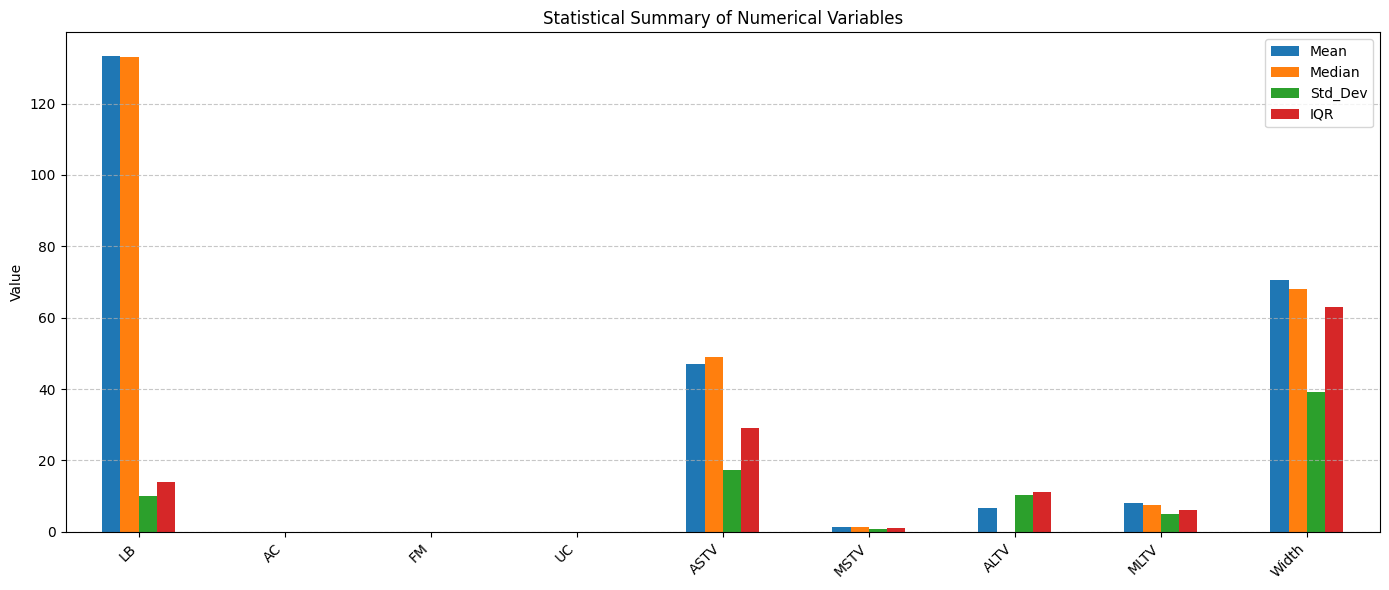

In [23]:
summary.plot(kind="bar", figsize=(14,6))
plt.title("Statistical Summary of Numerical Variables")
plt.ylabel("Value")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [24]:
skew_check = pd.DataFrame({
    "Mean": df[num_cols].mean(),
    "Median": df[num_cols].median(),
    "Difference (Mean - Median)": df[num_cols].mean() - df[num_cols].median()
})

skew_check

,Mean,Median,Difference (Mean - Median)
LB,133.293227,133.000000,0.293227
AC,0.003183,0.001689,0.001494
FM,0.001595,0.000000,0.001595
UC,0.004396,0.004513,-0.000117
ASTV,47.126383,49.000000,-1.873617
MSTV,1.304856,1.200000,0.104856
ALTV,6.756783,0.000000,6.756783
MLTV,8.067652,7.450000,0.617652
Width,70.618097,68.000000,2.618097


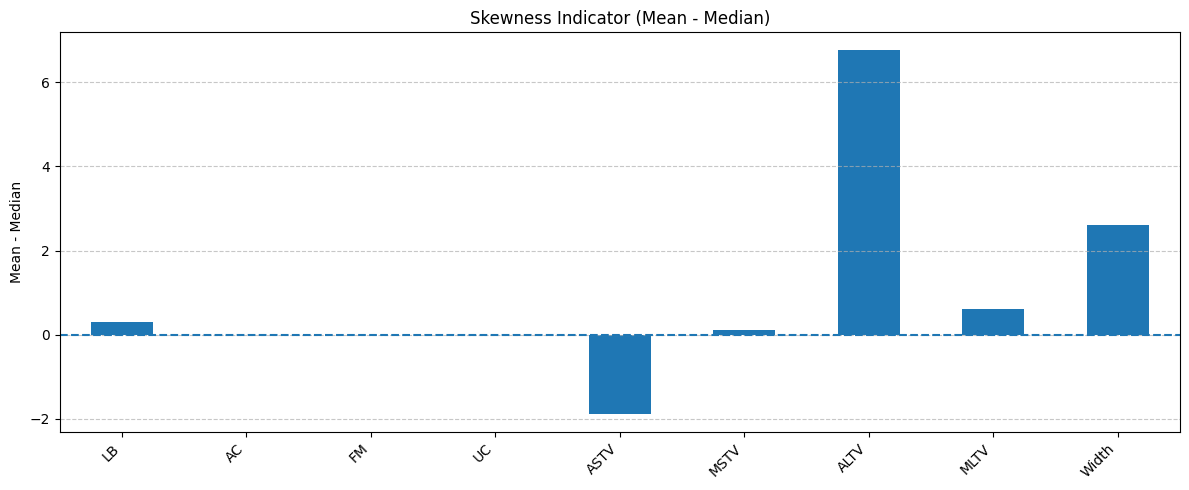

In [25]:
# Skewness check

diff = skew_check["Difference (Mean - Median)"]

plt.figure(figsize=(12,5))
diff.plot(kind="bar")
plt.axhline(0, linestyle="--")
plt.title("Skewness Indicator (Mean - Median)")
plt.ylabel("Mean - Median")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


In [26]:
insights = []

for col in num_cols:
    if df[col].mean() > df[col].median():
        insights.append(f"{col} is right-skewed")
    elif df[col].mean() < df[col].median():
        insights.append(f"{col} is left-skewed")

insights

['LB is right-skewed',
 'AC is right-skewed',
 'FM is right-skewed',
 'UC is left-skewed',
 'ASTV is left-skewed',
 'MSTV is right-skewed',
 'ALTV is right-skewed',
 'MLTV is right-skewed',
 'Width is right-skewed']

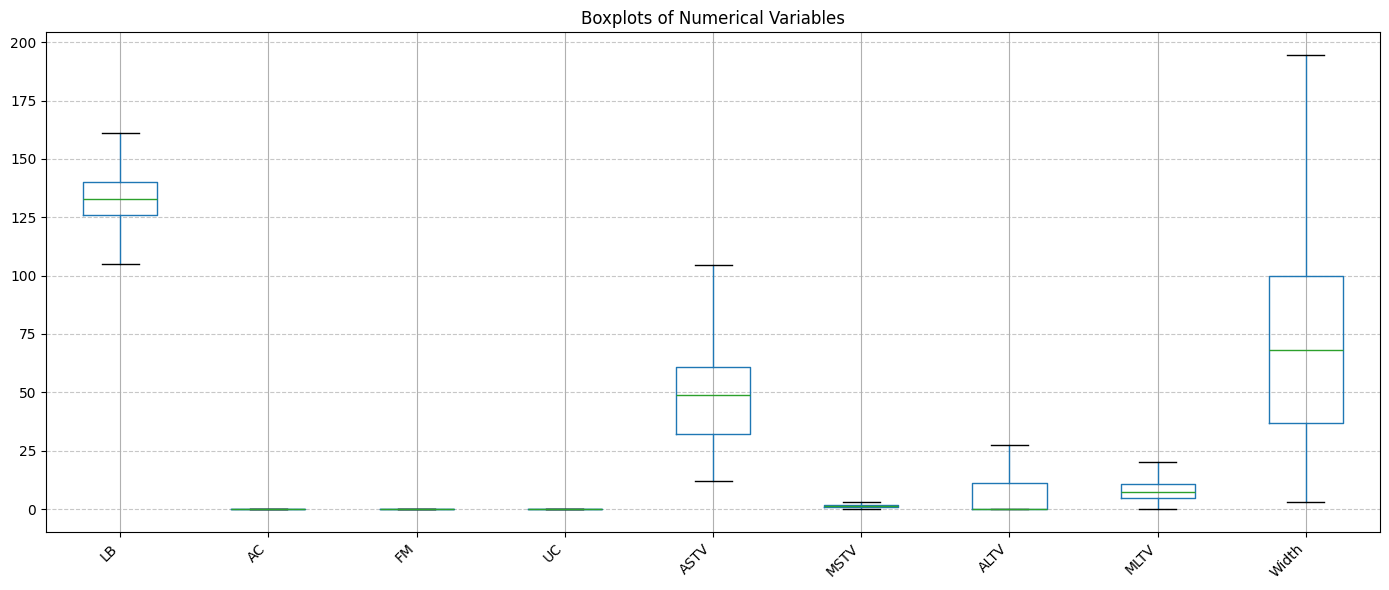

In [27]:
# Boxplots best visual for Outliers
plt.figure(figsize=(14,6))
df[num_cols].boxplot()
plt.title("Boxplots of Numerical Variables")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

Data Visualization

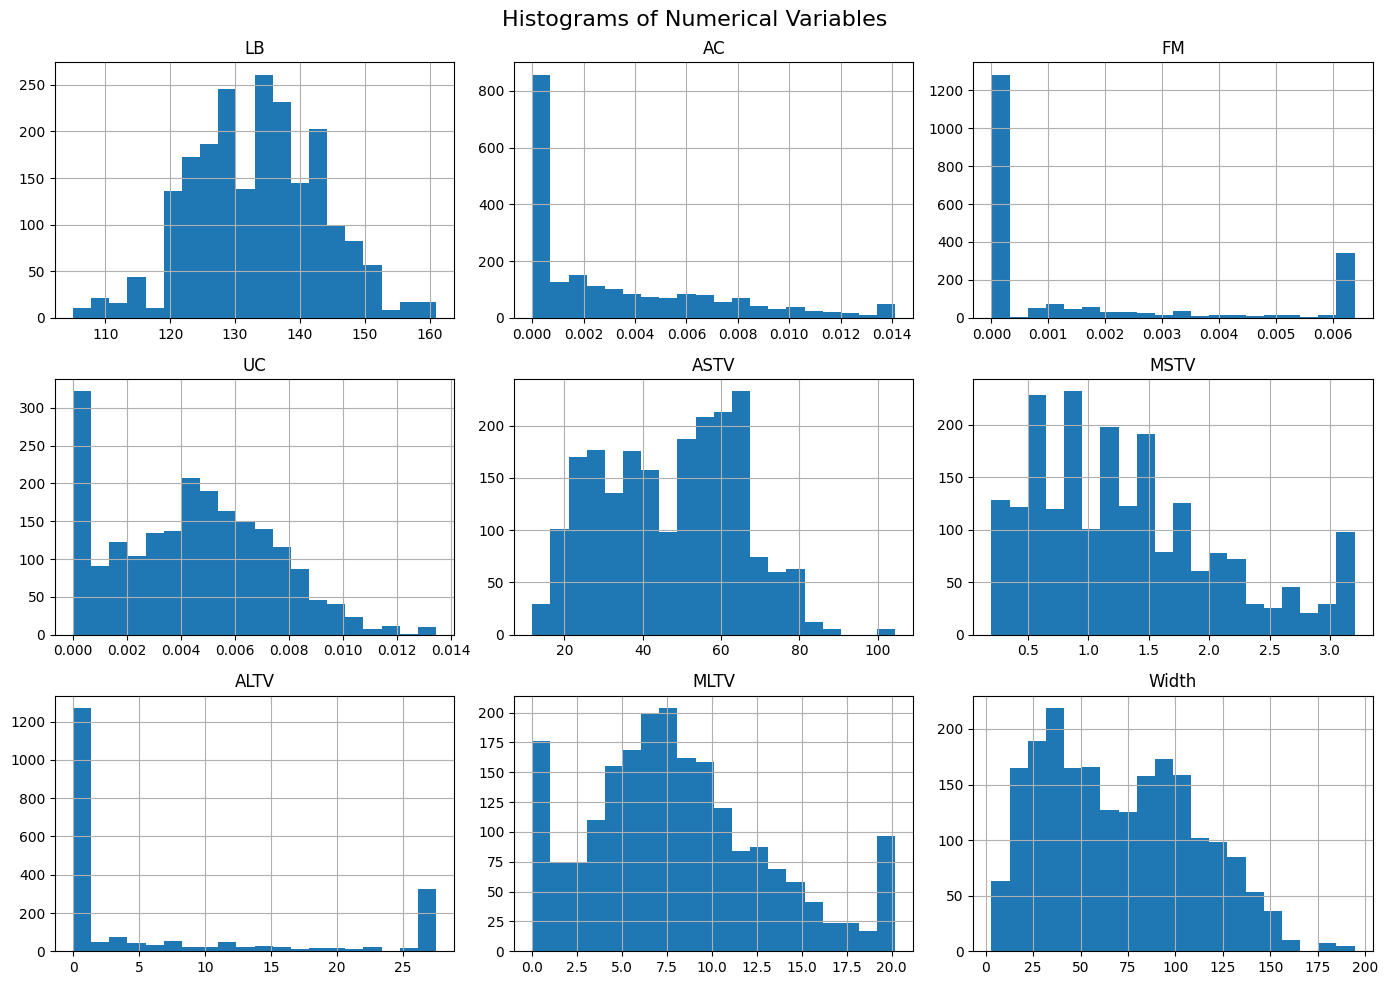

In [28]:
df[num_cols].hist(bins=20, figsize=(14,10))
plt.suptitle("Histograms of Numerical Variables", fontsize=16)
plt.tight_layout()
plt.show()


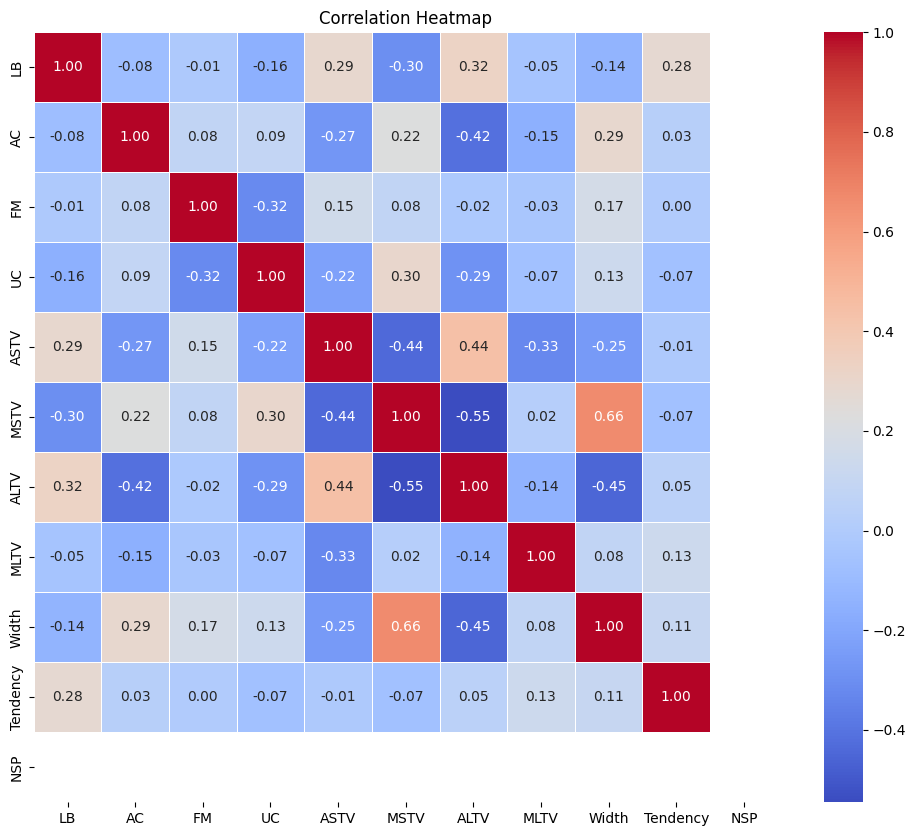

In [29]:
plt.figure(figsize=(12, 10))
corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

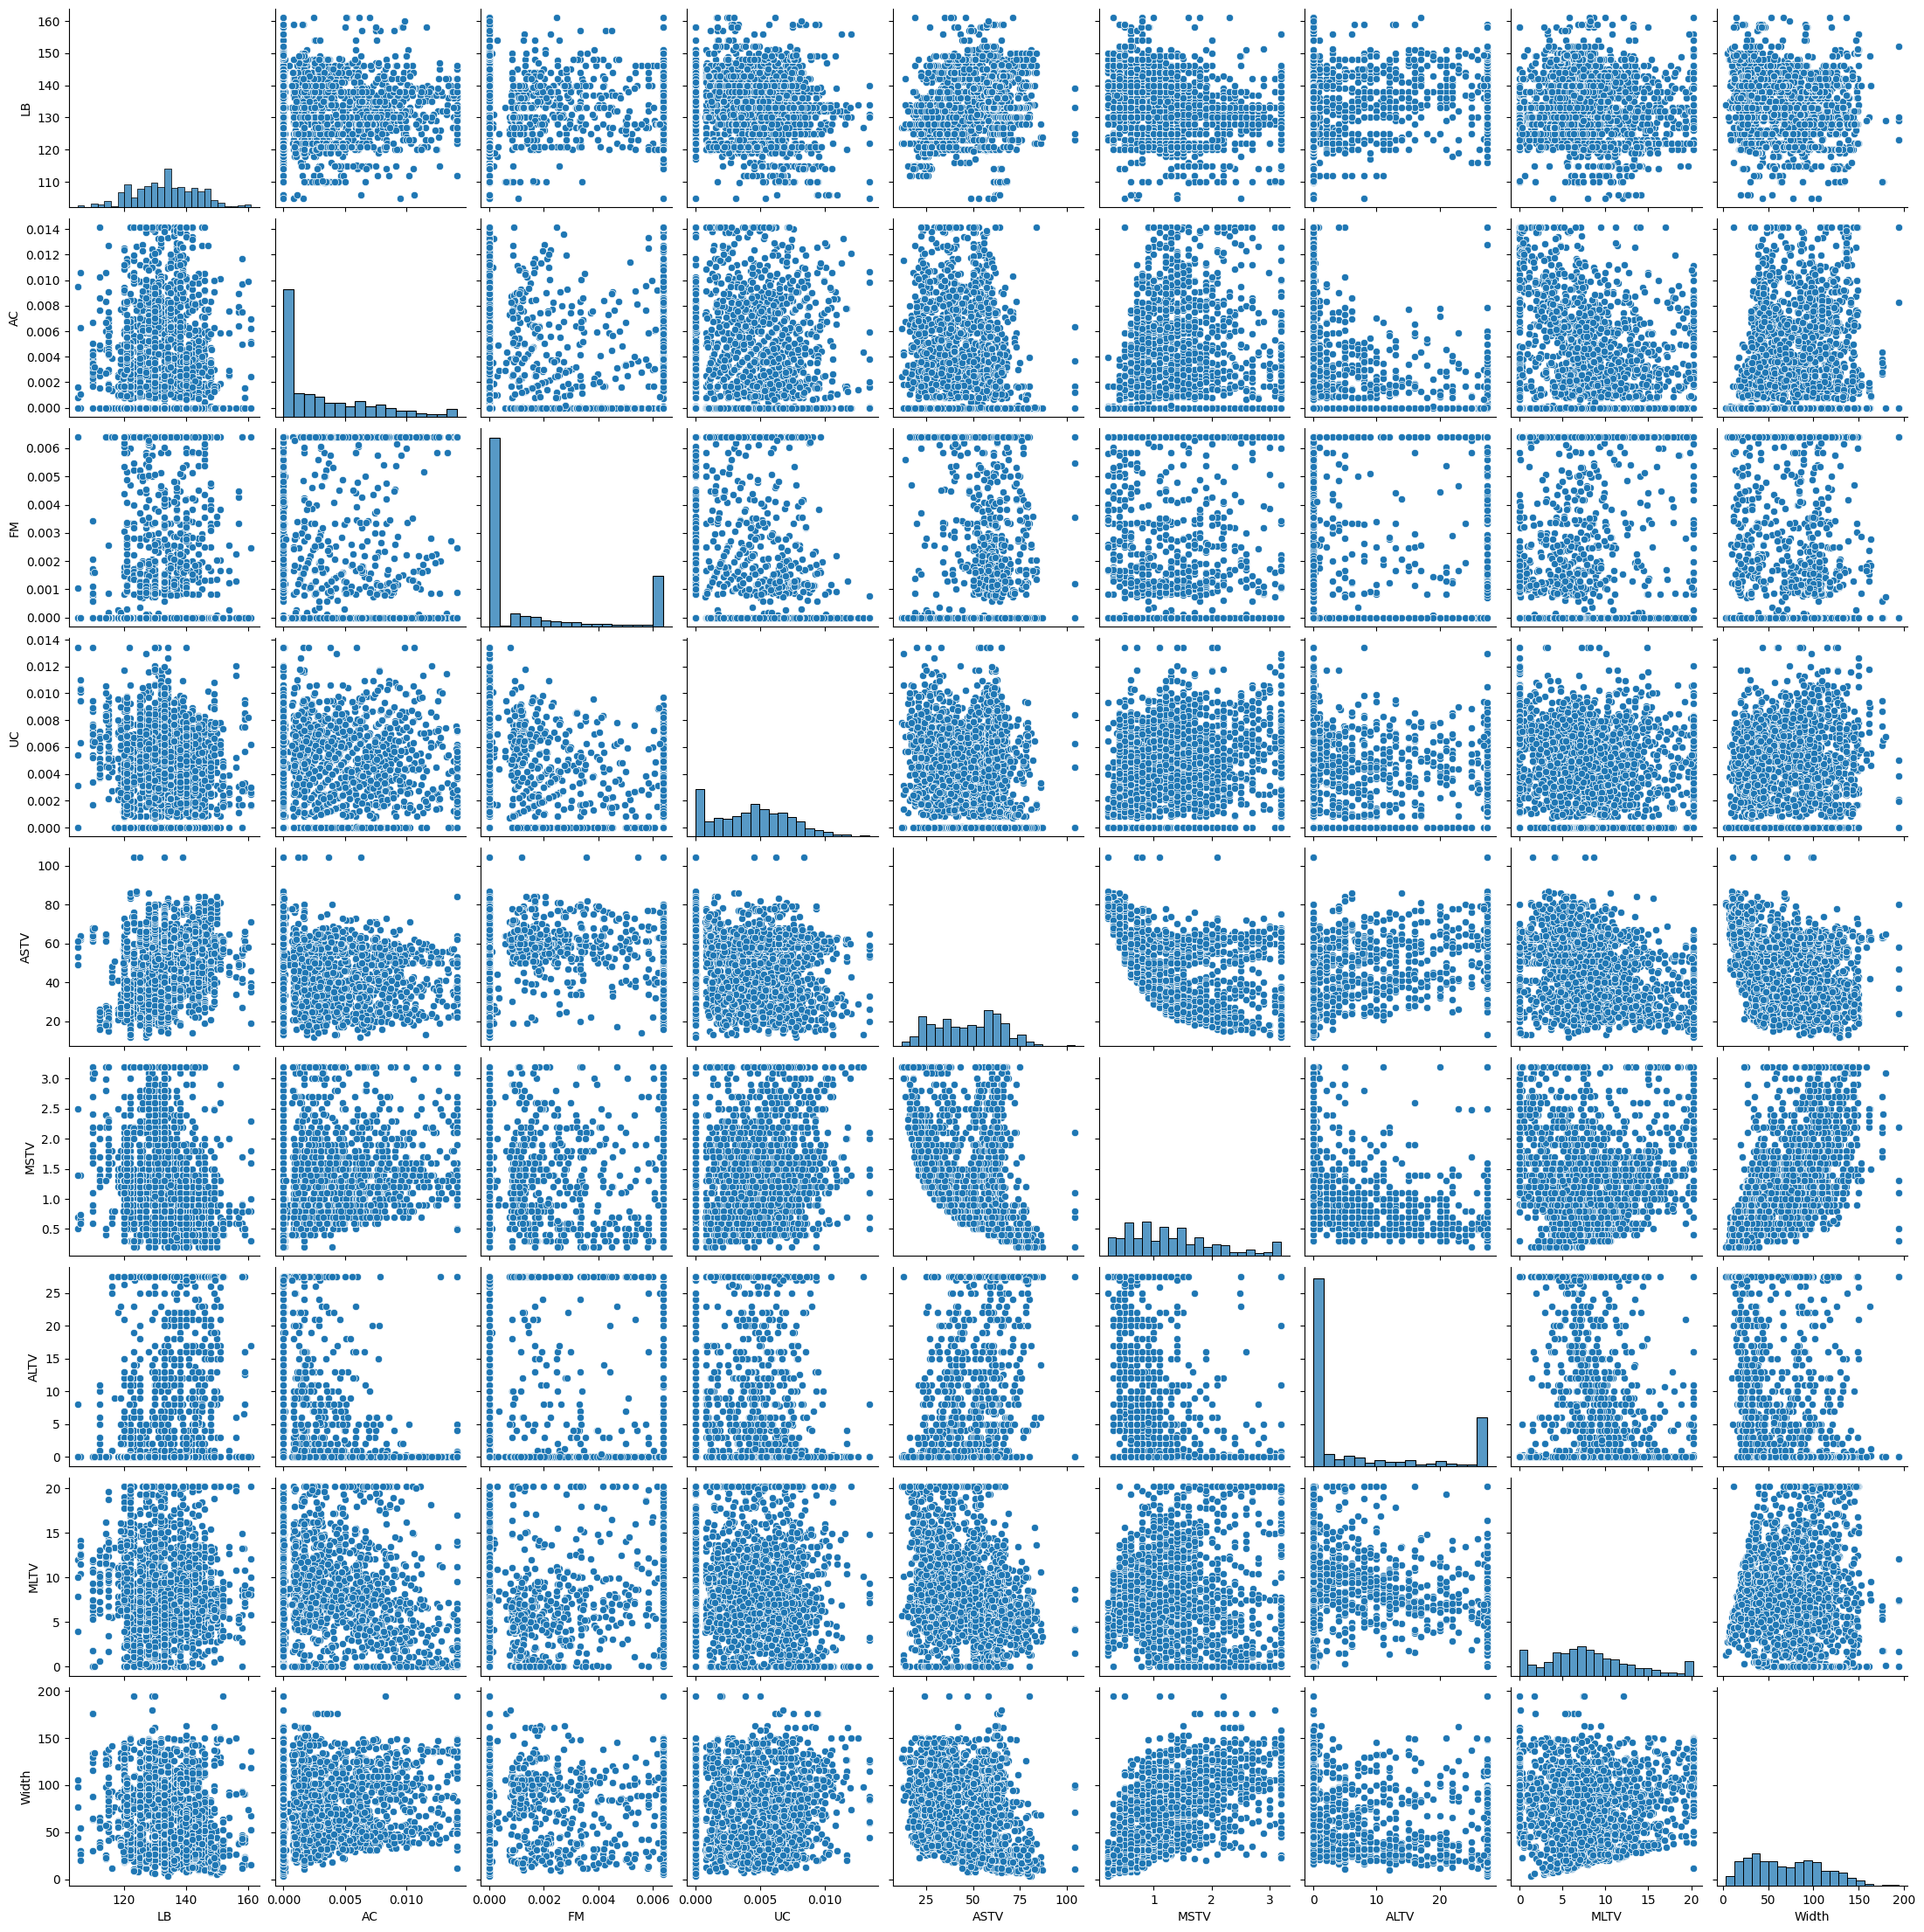

In [30]:
sns.pairplot(df[num_cols])
plt.show()


##Pattern Recognition and Insights


###Correlations Between Variables

During the exploratory analysis, several relationships between variables were observed:

`Strong correlations` were identified between key numerical features, indicating that changes in one variable are often associated with predictable changes in another.

`Moderate correlations` suggest partial dependence, where variables influence outcomes but are not the sole driving factors.

`Weak or no correlation` between some variables implies independence, meaning those features may not significantly impact the target variable.

#Implications:
Highly correlated variables may lead to multicollinearity, which should be handled carefully in predictive models.

Strongly correlated features can be prioritized for feature selection.

Weakly correlated variables may still provide value when combined with others
in non-linear models.

###Trends and Patterns Over Time

When examining the data over time, the following trends were identified:

`Upward or downward trends` indicate growth or decline in certain metrics, which may reflect changes in user behavior, business performance, or external factors.

`Seasonal patterns` (recurring peaks and drops) suggest time-dependent effects such as monthly cycles, holidays, or demand fluctuations.

`Sudden spikes or drops` may point to anomalies, special events, or data quality issues.

Implications:

Time-based trends can guide forecasting and planning.

Seasonal effects should be accounted for in time-series models.

Anomalies may require further investigation or separate handling.

###Conclusion

`Key Insights`

The dataset reveals meaningful relationships between variables, with certain features showing strong influence on outcomes.

Temporal analysis uncovers trends and recurring patterns, indicating that time plays an important role in the data.

Some variables show limited direct impact individually but may still contribute when combined with others.

`Impact on Decision-Making and Further Analysis`

These findings help in selecting relevant features, improving model performance, and avoiding redundancy.

Understanding correlations and trends supports data-driven decisions, such as optimizing strategies or predicting future behavior.

`Further analysis could include:`

Feature engineering based on correlated variables

Predictive modeling or classification

Deeper time-series or causal analysis